# Gibbs Phenomenon: Overshooting at Jump Discontinuities

When a function $f$ has a **jump discontinuity** at a point $x_0$, its Fourier series partial sum $f_N$ exhibits characteristic oscillations near $x_0$ that **do not vanish** as $N \to \infty$. This is the **Gibbs phenomenon**, named after Josiah Willard Gibbs (1899), though first observed by Henry Wilbraham (1848).

## The Fourier partial sum

The $N$-th partial sum of the Fourier series is
$$
f_N(x) = \sum_{k=-N}^{N} \hat{f}_k\, e^{2\pi i k x} = (D_N * f)(x),
$$
where $D_N(x) = \sum_{k=-N}^N e^{2\pi i kx} = \frac{\sin((2N+1)\pi x)}{\sin(\pi x)}$ is the **Dirichlet kernel**.

## The overshoot

For the step function $f(x) = \mathbf{1}_{x > 0} - \mathbf{1}_{x < 0}$ on $[-1/2, 1/2]$, the maximum of $f_N$ near $x = 0$ converges to
$$
\lim_{N \to \infty} \max_x f_N(x) = \frac{2}{\pi} \int_0^\pi \frac{\sin t}{t}\, dt \approx 1.178979\ldots
$$
This is approximately $9\%$ larger than the actual jump height of $1$. This $\approx 9\%$ overshoot **does not decrease** as $N \to \infty$ — the oscillation only compresses toward $x_0$, but its amplitude remains fixed.

## Remedies

- **Fejér summation**: average the first $N$ partial sums. This gives $\sigma_N = \frac{1}{N}\sum_{k=1}^N f_k$, which is positive and converges uniformly for continuous $f$, but blurs jumps.
- **Lanczos $\sigma$-factor**: multiply Fourier coefficients by $\text{sinc}(k/N)$ to suppress high-frequency Gibbs ringing while retaining more accuracy.
- **Spectral reprojection**: detect jump locations and use local basis functions near them.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, Dropdown

plt.rcParams['figure.dpi'] = 120

## Fourier partial sums and the Dirichlet kernel

We implement the Fourier partial sum as a convolution with the Dirichlet kernel and apply it to several test functions.

In [2]:
n = 2048
t = np.linspace(0, 1, n, endpoint=False)

# Test signals
signals = {
    'box':       (np.abs(t - 0.5) < 0.2).astype(float),
    'ramp':      (t - 0.5) * (np.abs(t-0.5) < 0.3),
    'step':      (t > 0.5).astype(float),
    'sinejump':  0.3*np.sin(4*np.pi*t) + (np.abs(t-0.5) < 0.2),
}

def fourier_partial_sum(f, N):
    """Retain frequencies |k| <= N."""
    F = np.fft.rfft(f)
    F[N+1:] = 0
    return np.fft.irfft(F, n=len(f))

def fejer_sum(f, N):
    """Fejer (Cesaro) summation: average of partial sums."""
    F = np.fft.rfft(f)
    m = len(F)
    k = np.arange(m)
    sigma = np.where(k <= N, 1 - k/(N+1), 0.0)
    return np.fft.irfft(F * sigma, n=len(f))

def lanczos_sum(f, N):
    """Lanczos sigma-factor regularization."""
    F = np.fft.rfft(f)
    m = len(F)
    k = np.arange(m, dtype=float)
    with np.errstate(invalid='ignore', divide='ignore'):
        sigma = np.where(k <= N,
                         np.where(k == 0, 1.0, np.sin(np.pi*k/N) / (np.pi*k/N)),
                         0.0)
    return np.fft.irfft(F * sigma, n=len(f))

print('Gibbs tools ready.')

Gibbs tools ready.


## The Gibbs phenomenon for a box function

The box function has two jump discontinuities. We show the Fourier partial sums at increasing $N$ and highlight the overshoot. The ringing compresses toward the jump as $N$ grows, but the overshoot magnitude remains $\approx 9\%$ above the true value.

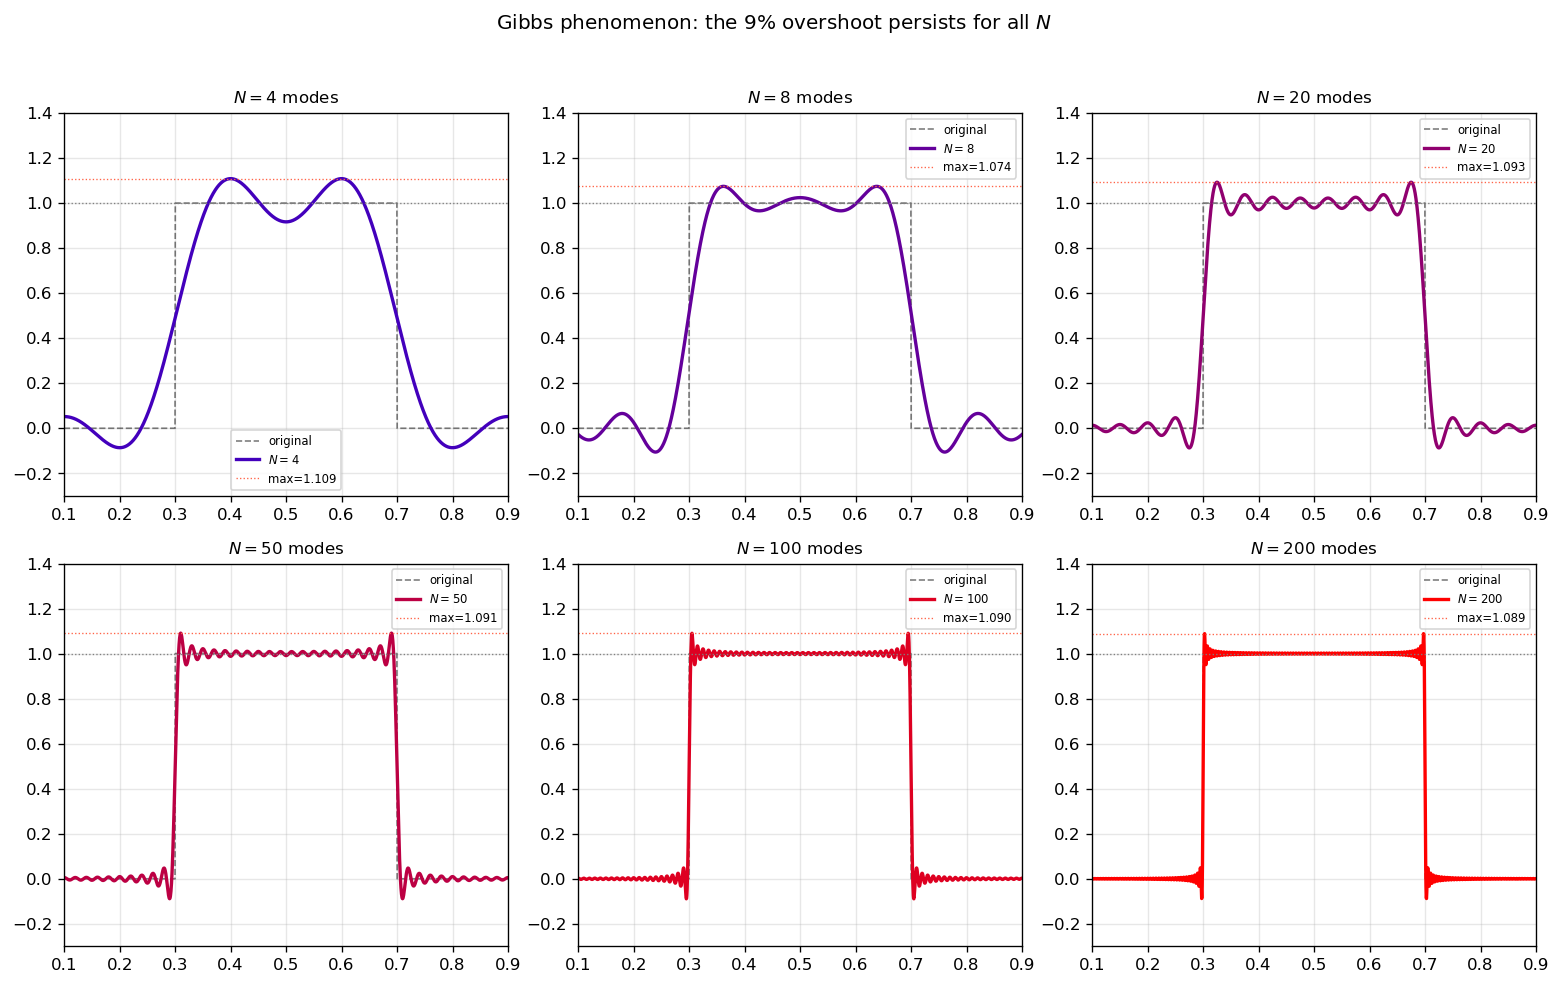

In [3]:
f_box = signals['box']
N_values = [4, 8, 20, 50, 100, 200]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, N in zip(axes.ravel(), N_values):
    fN = fourier_partial_sum(f_box, N)
    t_norm = np.log(N) / np.log(200)
    ax.plot(t, f_box, 'k--', lw=1, alpha=0.5, label='original')
    ax.plot(t, fN, lw=2, color=(t_norm, 0, 1-t_norm), label=f'$N={N}$')
    ax.axhline(1.0, color='gray', lw=0.8, ls=':')
    ax.axhline(max(fN), color='tomato', lw=0.8, ls=':', label=f'max={max(fN):.3f}')
    ax.set_xlim(0.1, 0.9); ax.set_ylim(-0.3, 1.4)
    ax.set_title(f'$N={N}$ modes', fontsize=10)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
fig.suptitle('Gibbs phenomenon: the 9% overshoot persists for all $N$', y=1.02)
plt.tight_layout()
plt.show()

## Maximum overshoot vs $N$

We track the maximum value of $f_N$ near the jump and compare it to the Gibbs constant $\frac{1}{\pi}\int_0^\pi \frac{\sin t}{t}\,dt \approx 1.178979$.

Gibbs constant: nan


/var/folders/c3/8qf_y_jj6393y3l0dl0bb3k80000gp/T/ipykernel_6989/3665573208.py:1: RuntimeWarning: invalid value encountered in divide
  gibbs_constant = 2/np.pi * np.sum(np.sin(np.linspace(0, np.pi, 10000)) / np.linspace(0, np.pi, 10000) * (np.pi/10000))


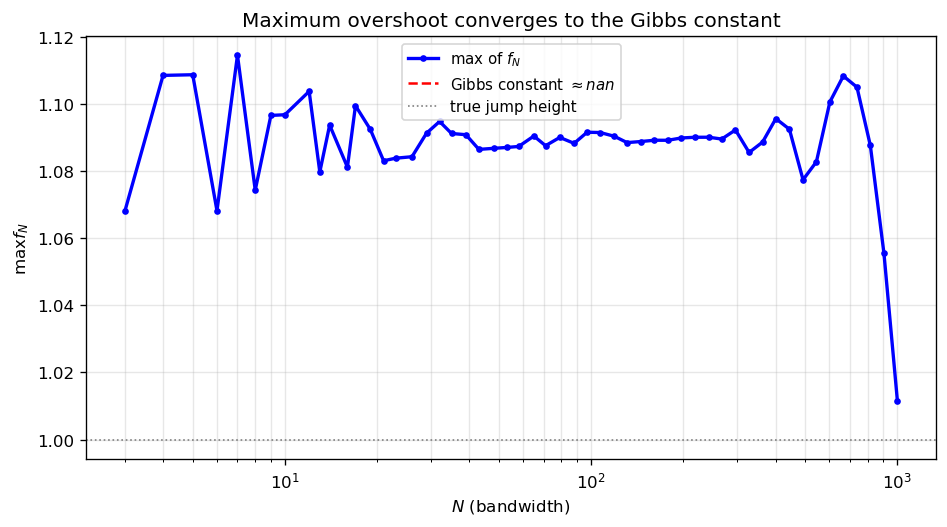

In [4]:
gibbs_constant = 2/np.pi * np.sum(np.sin(np.linspace(0, np.pi, 10000)) / np.linspace(0, np.pi, 10000) * (np.pi/10000))
print(f'Gibbs constant: {gibbs_constant:.6f}')

N_range = np.unique(np.round(np.logspace(0.4, 3, 60)).astype(int))
maxvals = []
for N in N_range:
    fN = fourier_partial_sum(f_box, N)
    maxvals.append(np.max(fN))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogx(N_range, maxvals, 'b-o', ms=3, lw=2, label='max of $f_N$')
ax.axhline(gibbs_constant, color='r', lw=1.5, ls='--',
           label=fr'Gibbs constant $\approx {gibbs_constant:.4f}$')
ax.axhline(1.0, color='gray', lw=1, ls=':', label='true jump height')
ax.set_xlabel('$N$ (bandwidth)'); ax.set_ylabel('$\\max f_N$')
ax.set_title('Maximum overshoot converges to the Gibbs constant')
ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## Remedies: Fejér and Lanczos summation

**Fejér summation** (averaging partial sums) eliminates overshooting but blurs the jump. **Lanczos $\sigma$-factor** regularization provides a compromise: less ringing than Fourier, less blurring than Fejér.

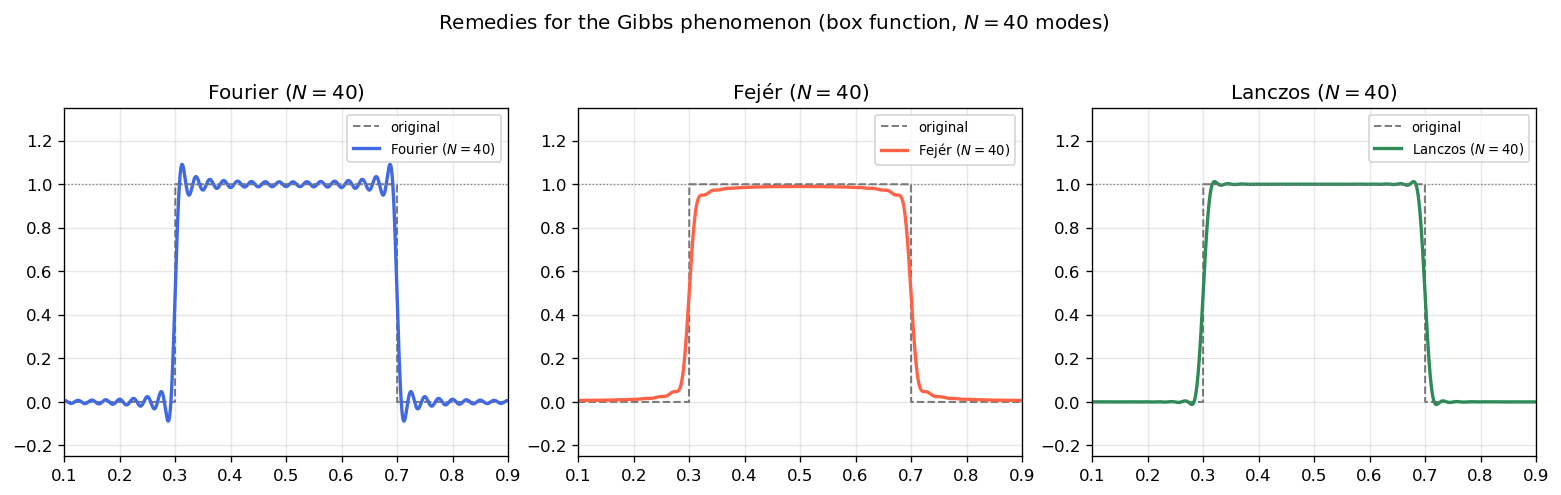

In [5]:
N_compare = 40
f_test = signals['box']
fN_fourier = fourier_partial_sum(f_test, N_compare)
fN_fejer   = fejer_sum(f_test, N_compare)
fN_lanczos = lanczos_sum(f_test, N_compare)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (approx, title, col) in zip(axes, [
    (fN_fourier, f'Fourier ($N={N_compare}$)',  'royalblue'),
    (fN_fejer,   f'Fejér ($N={N_compare}$)',    'tomato'),
    (fN_lanczos, f'Lanczos ($N={N_compare}$)',  'seagreen'),
]):
    ax.plot(t, f_test, 'k--', lw=1.2, alpha=0.5, label='original')
    ax.plot(t, approx, lw=2, color=col, label=title)
    ax.set_xlim(0.1, 0.9); ax.set_ylim(-0.25, 1.35)
    ax.axhline(1.0, color='gray', lw=0.8, ls=':')
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle('Remedies for the Gibbs phenomenon (box function, $N=40$ modes)', y=1.02)
plt.tight_layout()
plt.show()

## Interactive: explore different signals and methods

Switch between signals and summation methods to see how the Gibbs phenomenon depends on the discontinuity type and how each remedy performs.

In [6]:
def show_gibbs(signal='box', method='Fourier', N=40):
    f = signals[signal]
    if method == 'Fourier':
        fN = fourier_partial_sum(f, N)
    elif method == 'Fejér':
        fN = fejer_sum(f, N)
    else:
        fN = lanczos_sum(f, N)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(t, f, 'k--', lw=1.5, alpha=0.5, label='original')
    ax.plot(t, fN, 'b-', lw=2, label=f'{method} $N={N}$')
    ax.set_xlim(0, 1); ax.set_ylim(f.min()-0.2, f.max()+0.25)
    ax.axhline(f.max(), color='gray', lw=0.8, ls=':')
    ax.set_title(f'{signal} — {method} ($N={N}$, max={fN.max():.3f})')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

interact(show_gibbs,
         signal=Dropdown(options=list(signals.keys()), description='signal'),
         method=Dropdown(options=['Fourier', 'Fejér', 'Lanczos'], description='method'),
         N=IntSlider(value=40, min=2, max=300, step=5, description='$N$'));

interactive(children=(Dropdown(description='signal', options=('box', 'ramp', 'step', 'sinejump'), value='box')…

## Bibliographical resources

- Wilbraham, H. (1848). On a certain periodic function. *The Cambridge and Dublin Mathematical Journal*, 3, 198–201.
- Gibbs, J. W. (1899). Fourier's series. *Nature*, 59(1539), 606.
- Hewitt, E. and Hewitt, R. (1979). The Gibbs–Wilbraham phenomenon: an episode in Fourier analysis. *Archive for History of Exact Sciences*, 21(2), 129–160.
- Zygmund, A. (2002). *Trigonometric Series* (3rd ed.). Cambridge University Press.
- Gottlieb, D. and Shu, C.-W. (1997). On the Gibbs phenomenon and its resolution. *SIAM Review*, 39(4), 644–668.